### <u>**Data understanding:</u><span style="color:#F7931A;"> Erster Eindruck</span>**

In [27]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# globaler Stil für Matplotlib Plots
plt.close("all")
plt.rcParams.update({
    # --- Außenbereich (Figure) ---
    "figure.facecolor": "#181c24",

    # --- Innenbereich (Plot / Kursverlauf) ---
    "axes.facecolor": "#1e222d",

    # --- Rahmen / Spines ---
    "axes.edgecolor": "#cfcfcf",
    "axes.linewidth": 1.2,

    # --- Text ---
    "text.color": "#e6e6e6",
    "axes.labelcolor": "#e6e6e6",
    "axes.titlecolor": "#e6e6e6",
    "xtick.color": "#cfcfcf",
    "ytick.color": "#cfcfcf",

    # --- Grid ---
    "axes.grid": True,
    "grid.color": "#3a3f4b",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.8,

    # --- Linien ---
    "lines.linewidth": 2.0,

    # --- Legende ---
    "legend.facecolor": "#1e222d",
    "legend.edgecolor": "#cfcfcf",
    "legend.framealpha": 1.0
})

In [28]:
# Daten herunterladen & Data Frame erstellen
df = yf.download("BTC-USD", start="2016-01-10", end="2026-01-10")
# prüfen der Daten auf Nullwerte
df.columns = df.columns.get_level_values(0)
df.columns
# Sortieren der Daten nach datum
df= df.sort_index()
df.index.name = 'Date'
df.columns


[*********************100%***********************]  1 of 1 completed


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [29]:
# Erster Überblick über die Daten
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3653 entries, 2016-01-10 to 2026-01-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3653 non-null   float64
 1   High    3653 non-null   float64
 2   Low     3653 non-null   float64
 3   Open    3653 non-null   float64
 4   Volume  3653 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 171.2 KB


In [30]:
# Erste paar Zeilen des Data Frames anzeigen
df.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-01-10,447.990997,448.308990,440.351013,448.238007,35995900
2016-01-11,448.428009,450.661987,443.855011,448.697998,40450000
2016-01-12,435.690002,448.182007,435.690002,448.182007,115607000
2016-01-13,432.371002,435.186005,424.442993,434.665009,173888000
2016-01-14,430.306000,433.324005,427.845001,432.287994,43945500
2016-01-15,364.330994,430.255005,364.330994,430.255005,153351008
2016-01-16,387.536011,390.557007,354.914001,365.072998,120352000
2016-01-17,382.299011,390.964996,380.092010,387.152008,45319600
2016-01-18,387.167999,388.104004,376.665009,381.733002,54403900


In [31]:
# Letzte Zeilen des Data Frames anzeigen
df.tail(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171
2026-01-03,90603.187500,90679.570312,89328.070312,89945.054688,20774828592
2026-01-04,91413.492188,91712.585938,90595.101562,90603.000000,26770491368
2026-01-05,93882.554688,94762.070312,91414.625000,91414.625000,53376407252
2026-01-06,93729.031250,94395.296875,91286.546875,93876.945312,52430605257
2026-01-07,91308.054688,93738.789062,90601.804688,93727.468750,43461295053
2026-01-08,91027.125000,91485.851562,89233.875000,91309.640625,42386697030


In [32]:
# Explizites nachprüfen auf nan Werte
df.isnull().sum()


Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [33]:
# Statistische Übersicht der Daten
df.describe()
# Erste Erkenntnissee schließen über die verschiednen Metriken

Price,Close,High,Low,Open,Volume
count,3653.000000,3653.000000,3653.000000,3653.000000,3.653000e+03
mean,30495.961651,31084.502607,29826.243643,30472.460341,2.450932e+10
std,32174.552076,32702.731653,31589.297553,32163.722976,2.286277e+10
min,364.330994,374.950012,354.914001,365.072998,2.851400e+07
25%,6465.410156,6547.140137,6353.729980,6455.450195,5.386320e+09
50%,17429.500000,17853.939453,16924.050781,17446.359375,2.059770e+10
75%,46737.480469,47998.097656,45579.808594,46716.636719,3.568211e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


### <u>**Data understanding:</u><span style="color:#F7931A;"> EDA simple</span>**

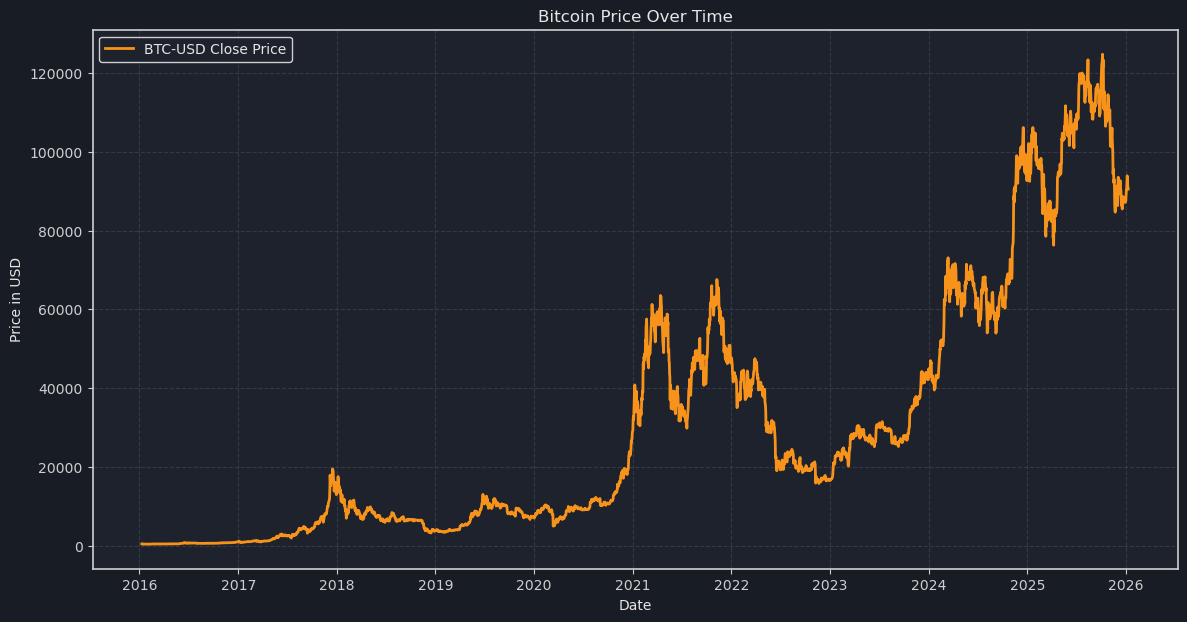

In [34]:
# Zeitreihe  gesamt  
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='BTC-USD Close Price', color
='#F7931A')
plt.title('Bitcoin Price Over Time')
# Achsenbeschriftungen und Legende
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()

plt.show()

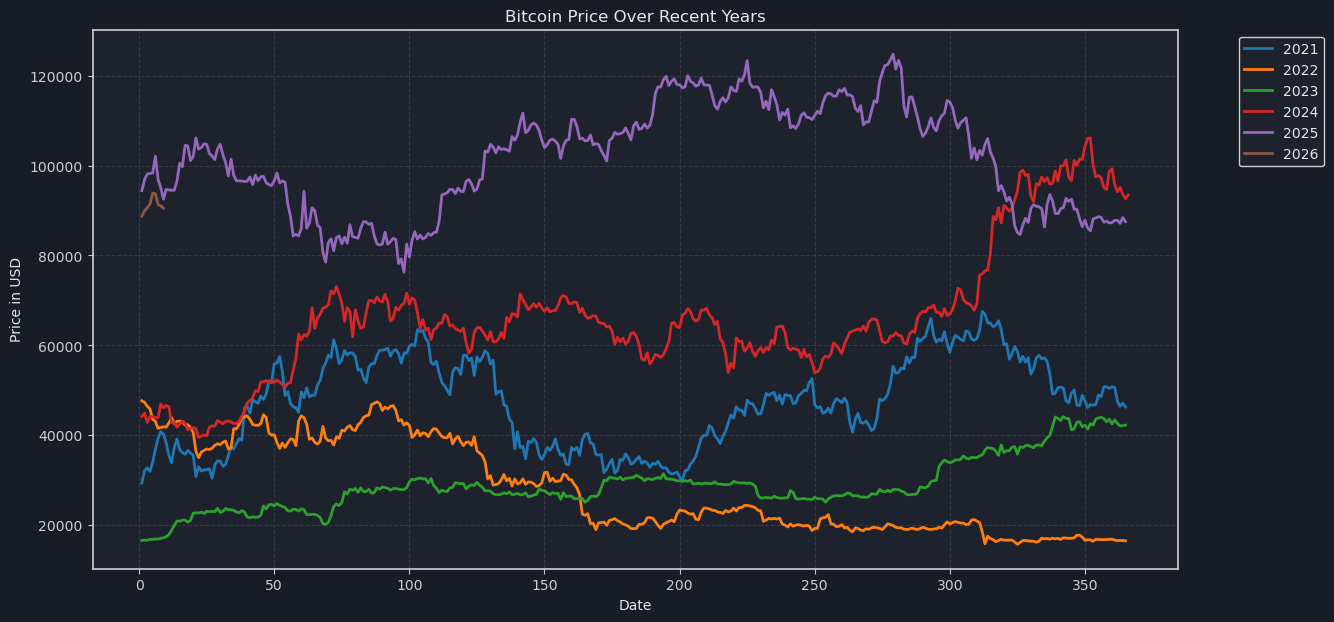

In [35]:
# Zeitreihe pro Jahr
fig, ax = plt.subplots(figsize=(14, 7))
# Gruppieren der Daten nach Jahren
for year, x in df.groupby(df.index.year):
    if 2021 <= year <= 2026:
        ax.plot(
            x.index.dayofyear,
            x["Close"],
            label=str(year)
        )
# Achsentitel und Beschriftungen
ax.set_title("Bitcoin Price Over Recent Years")
ax.set_xlabel("Date")
ax.set_ylabel("Price in USD")
# Legende außerhalb des Plots
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [36]:
# PLOT 10 Jahre war nicht sinnvoll in absoluter Darstellung, 
# deshalb wechsel zu 6 jahre


In [37]:
# Plausibilitätscheck by Hand (Stichproben)
df.loc['2021'].iloc[[0, 50, 100, 150, 200]] # innere [] für Liste von Postionen, äußere [] für Zugriff auf iloc
df.loc['2022'].iloc[[0, 50, 100, 150, 200]]
df.loc['2023'].iloc[[0, 50, 100, 150, 200]]
# visueller Vergleich mit Plot


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700
2023-02-20,24829.148438,25020.458984,23927.910156,24336.623047,28987376573
2023-04-11,30235.058594,30509.083984,29609.300781,29653.679688,20121259843
2023-05-31,27219.658203,27831.677734,26866.453125,27700.529297,15656371534
2023-07-20,29792.015625,30195.531250,29638.095703,29915.250000,14655207121


### <u>**Data understanding:</u><span style="color:#F7931A;"> EDA complex</span>**

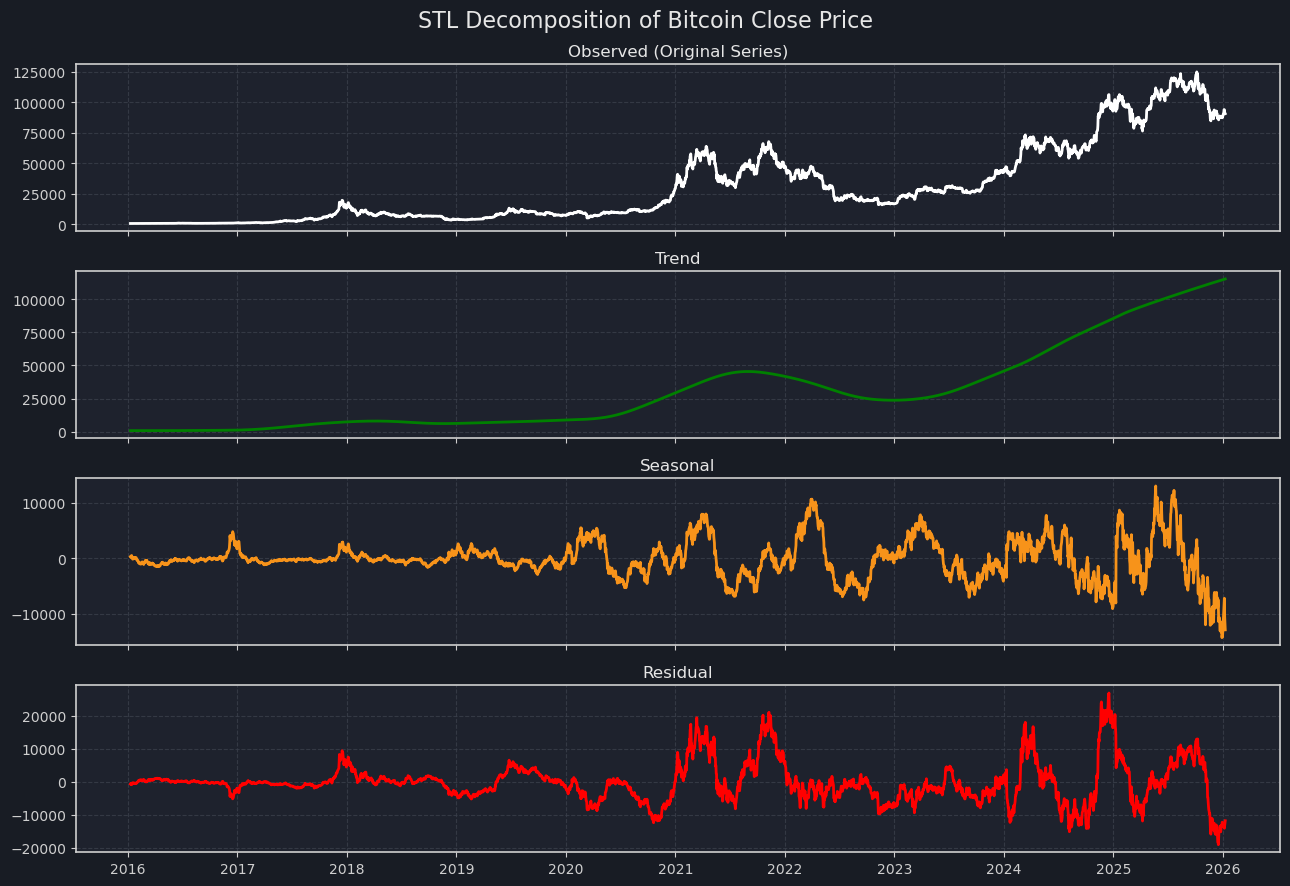

In [38]:
# STL Decomposition 
# Trend, Saisonalität (wiederkehrende Muster)und Residuen (Zufall/Rauschen/Unerklärter Teil)
from statsmodels.tsa.seasonal import STL # Import STL Dekompositionmethode
stl = STL(df['Close'], period=365)  # period=365 für jährliche Saisonalität
result = stl.fit() # Führt Dekomposition durch
seasonal = result.seasonal
trend = result.trend
residual = result.resid

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True) # sharex = gemeinsame x-Achse, supplots in einer Spalte 
 

axes[0].plot(result.observed, color='white')
axes[0].set_title('Observed (Original Series)')

axes[1].plot(result.trend, color='green')
axes[1].set_title('Trend')

axes[2].plot(result.seasonal, color='#F7931A')
axes[2].set_title('Seasonal')

axes[3].plot(result.resid, color='red')
axes[3].set_title('Residual')

fig.suptitle('STL Decomposition of Bitcoin Close Price', fontsize=16)
plt.tight_layout()
plt.show()

In [39]:

# Top 5% Extremwerte der Residuen gesamter Zeithorizont (für besseres Verständnis der Ausreißer)
threshold = np.quantile(np.abs(residual), 0.95)
top5 = residual[np.abs(residual) >= threshold]

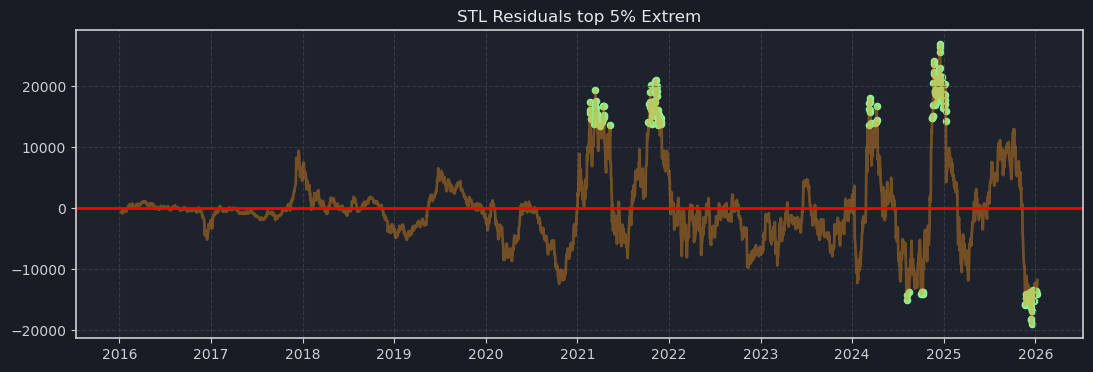

In [40]:
plt.figure(figsize=(13,4))
plt.plot(residual, color='#F7931A', alpha=0.4)
plt.scatter(top5.index, top5.values, color="lightgreen", s=20)
plt.axhline(0, color="red")
plt.title("STL Residuals top 5% Extrem")
plt.show()

### <u>**Data preparation:</u><span style="color:#F7931A;"> Train-Test-Split</span>**

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [50]:
# Allgemeinen Test-Train-Split bei Zeitreihen beachten
y = df['Close'].sort_index()
# Zielvariable  und split festlegen
split_date = y.index[int(len(y)*0.8)]  # 80% der daten für Training
y_train = y.loc[:split_date]
y_test = y.loc[split_date:]


### <u>**Data preparation:</u><span style="color:#F7931A;"> Duplikate entfernen</span>**

In [73]:
df.duplicated().sum()

np.int64(0)

### <u>**Data preparation:</u><span style="color:#F7931A;"> Ausreißer checken (IQR)</span>**

In [74]:
Q1 = df["Close"].quantile(0.25)
Q3 = df["Close"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Close"] < lower) | (df["Close"] > upper)]
print(len(outliers))

137


In [ ]:
137 / 3650 = 0.0375 = 3.75%
#3-5% Ausreißer sind akzeptabel bei Finanzdaten


### <u>**Data preparation:</u><span style="color:#F7931A;"> Stationarität (ARIMA)</span>**

In [72]:
# Prüfung Stationarität der Zeitreihe mit ADF Test
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(y_train)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))

ADF Statistic: -1.3550396280288255
p-value: 0.6036309865518176
Critical Value (1%): -3.433
Critical Value (5%): -2.863
Critical Value (10%): -2.567


In [ ]:
# p-Value > 0.05 => Zeitreihe ist nicht stationär, weitere Transformationen notwendig
# ADF Statistic muss kleiner sein als kritische Werte um Stationarität zu bestätigen

### <u>**Modeling:</u><span style="color:#F7931A;"> Naive Forecast</span>**

In [51]:
# Naive Forecast als erstes Prognosemodell
y_naive_forecast = y_train.iloc[-1]  # Letzter bekannter wert der trainingsdaten
y_naive_forecast = pd.Series(
    y_naive_forecast, 
    index=y_test.index # Zeitindex der Testdaten
    )  

# Konfidenzintervall festlegen (95% Konfidenzintervall)
conf_int = pd.DataFrame({
    'lower': y_naive_forecast * 0.95,
    'upper': y_naive_forecast * 1.05
})

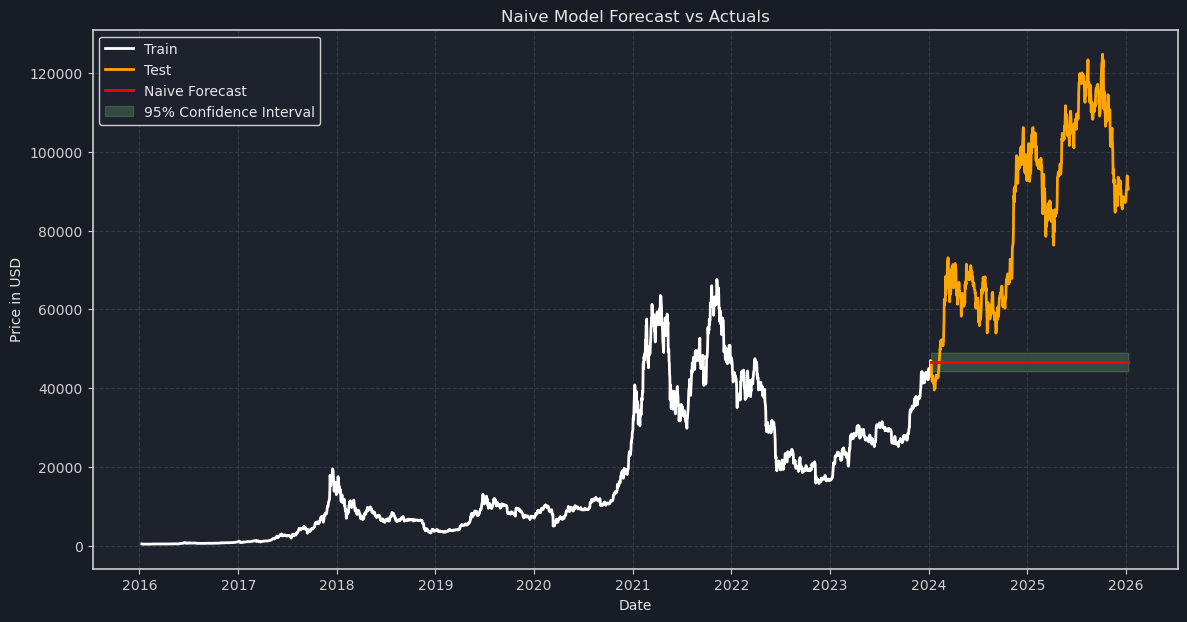

In [52]:
# Plot der Ergebnisse
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train, label='Train', color='white') 
plt.plot(y_test.index, y_test, label='Test', color='orange')
plt.plot(y_naive_forecast.index, y_naive_forecast, label='Naive Forecast', color='red')
# Konfidenzintervalle hinzufügen (optional)
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='lightgreen',
                 alpha=0.2,
                 label='95% Confidence Interval')
# Achsentitel und Beschriftungen 
plt.title('Naive Model Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()
plt.show()


In [53]:
# Naive Modell Bewertung (MAE, MSE, RMSE)
mae_naive = mean_absolute_error(y_test, y_naive_forecast)
mse_naive = mean_squared_error(y_test, y_naive_forecast)
rmse_naive = np.sqrt(mse_naive)
mae_naive, mse_naive, rmse_naive

(38060.22390133379, 1899315722.109993, np.float64(43581.13952284856))

### <u>**Modeling:</u><span style="color:#F7931A;"> ETS-Modell (Exponential Smoothing)</span>**

In [54]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [55]:
# ETS Modell erstellen und anpassen
model = ExponentialSmoothing(
    y_train,
    trend='add',  # additive Trendkomponente
    seasonal=None,  # keine Saisonalität
    initialization_method="estimated"  # Initialisierungsmethode
)
ets_fit = model.fit()
# Ausgabe Modell-Objekt

# Forecast für Testzeitraum erstellen
y_ets_forecast = ets_fit.forecast(steps=len(y_test))
y_ets_forecast.index = y_test.index  # Index des Forecasts anpassen

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


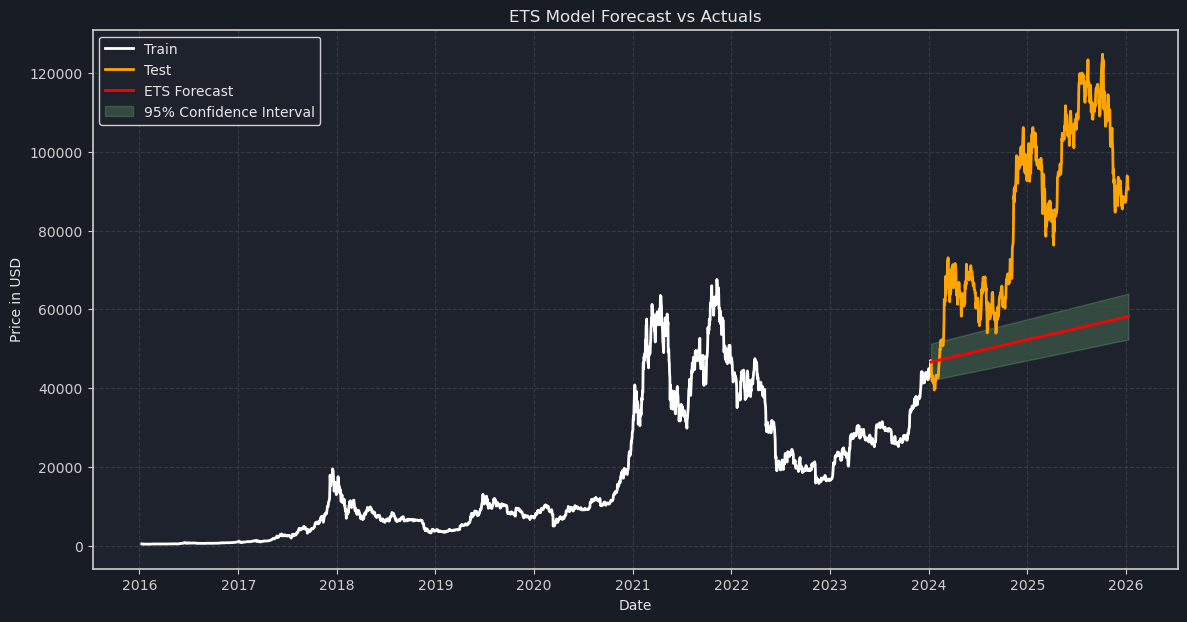

In [60]:

# Plot der Ergebnisse mit Konfidenzintervallen
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train, label='Train', color='white')
plt.plot(y_test.index, y_test, label='Test', color='orange')
plt.plot(y_ets_forecast.index, y_ets_forecast, label='ETS Forecast', color='red')



# Konfidenzintervalle
conf_int_ets = pd.DataFrame({
    'lower': y_ets_forecast * 0.9,
    'upper': y_ets_forecast * 1.1
})
plt.fill_between(conf_int_ets.index, 
                    conf_int_ets.iloc[:, 0],
                    conf_int_ets.iloc[:, 1],
                    color='lightgreen',
                    alpha=0.2,
                    label='95% Confidence Interval')

# Achsentitel und Beschriftungen
plt.title('ETS Model Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()
plt.show()



In [61]:
# Modelbewertung ETS (MAE, MSE, RMSE)
mae_ets = mean_absolute_error(y_test, y_ets_forecast)
mse_ets = mean_squared_error(y_test, y_ets_forecast)
rmse_ets = np.sqrt(mse_ets)
mae_ets, mse_ets, rmse_ets

(32312.866199342694, 1387123780.1644027, np.float64(37244.110677587705))

### <u>**Modeling:</u><span style="color:#F7931A;"> ARIMA</span>**

In [62]:
# geht nicht from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

In [63]:
# Arima Modell als weiteres Vergleichsmodell

arima_modell = ARIMA(
    y_train,
    order=(5, 1, 0)  # (p, d, q) Parameter des ARIMA Modells ????? Erklären
)
arima_fit = arima_modell.fit()

y_arima_forecast = arima_fit.forecast(steps=len(y_test))
y_arima_forecast.index = y_test.index
# frequency D passt Daten im df sind daily 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [64]:
forecast_res = arima_fit.get_forecast(steps=len(y_test)) # Forecast Object

y_arima_mean = forecast_res.predicted_mean # Mittelwert Punktprognose
y_arima_mean.index = y_test.index

# Konfidenzintervalle 95%
conf_int = forecast_res.conf_int(alpha=0.05)  
conf_int.index = y_test.index

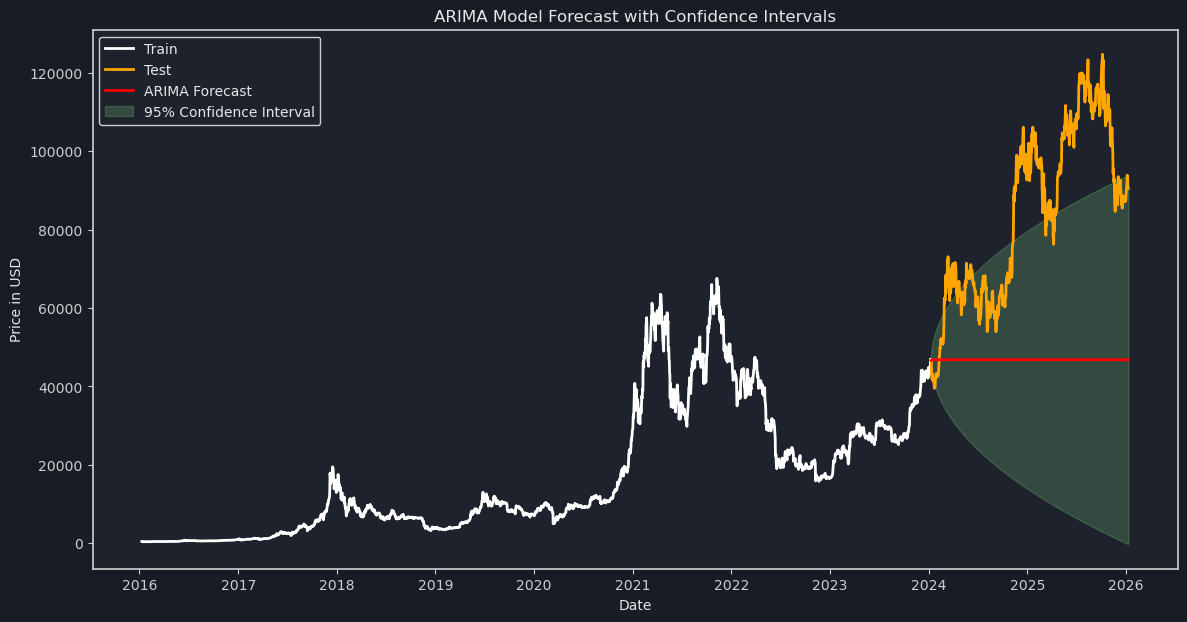

In [65]:
# PLot mit Konfidenzintervallen
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train, label='Train', color='white')
plt.plot(y_test.index, y_test, label='Test', color='orange')
plt.plot(y_arima_mean.index, y_arima_mean, label='ARIMA Forecast',
            color='red')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='lightgreen',
                 alpha=0.2,
                 label='95% Confidence Interval')
plt.title('ARIMA Model Forecast with Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()
plt.grid()
plt.show()

In [66]:
# Modelbewertung ARIMA (MAE, MSE, RMSE)
mse_arima = mean_squared_error(y_test, y_arima_forecast)
mae_arima = mean_absolute_error(y_test, y_arima_forecast)
rmse_arima = np.sqrt(mse_arima)

mae_arima, rmse_arima

(37902.283390256125, np.float64(43432.573722423935))

In [67]:
# Gegenüberstellung der Modellbewertungen (MAE, MSE, RMSE)
results = pd.DataFrame({
    'Model': ['Naive', 'ETS', 'ARIMA'],
    'MAE': [mae_naive, mae_ets, mae_arima],
    'MSE': [mse_naive, mse_ets, mse_arima],         
    'RMSE': [rmse_naive, rmse_ets, rmse_arima]
})
results = results.set_index('Model')
results = results.round(2)
results

,MAE,MSE,RMSE
Model,,,
Naive,38060.22,1.899316e+09,43581.14
ETS,32312.87,1.387124e+09,37244.11
ARIMA,37902.28,1.886388e+09,43432.57


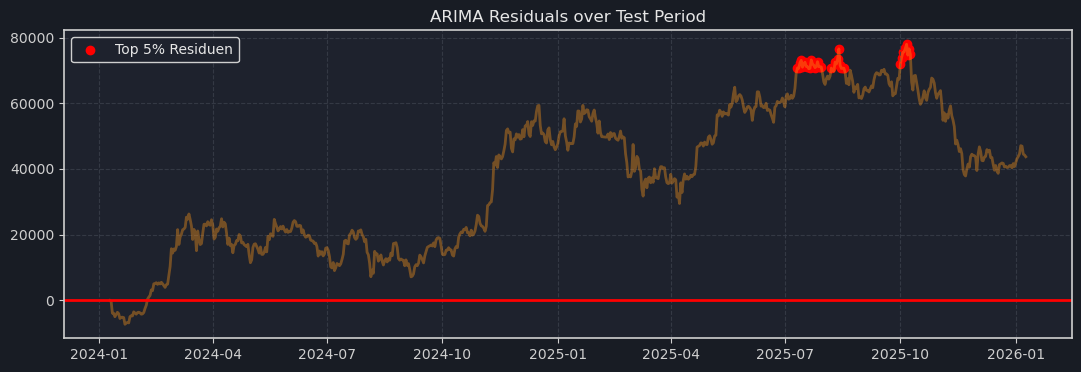

In [71]:
# Residuenanalyse des Testzeitraums für das ARIMA Modell
# Schwelle oberste 5% Residuen
residuals_arima = y_test - y_arima_forecast
threshold = np.quantile(np.abs(residuals_arima), 0.95)
top5_residuals = residuals_arima[np.abs(residuals_arima) >= threshold]

#Plot der Residuen mit Hervorhebung der Top 5% Extremwerte
plt.figure(figsize=(13,4))
plt.plot(residuals_arima, color='#F7931A', alpha=0.4)
plt.scatter(top5_residuals.index, top5_residuals, color='red', label='Top 5% Residuen')
plt.axhline(0, color="red")
plt.title("ARIMA Residuals over Test Period")
plt.legend()
plt.show()

In [ ]:
# Evaluierung der Residuen des ARIMA Modells